# ARIMA-Tools: Development and Testing

**Miguel A. Arranz**  
**Applied Time Series Econometrics (ATSE)**

---

This notebook is used for the development, testing, and validation of the
`ARIMA-Tools` Python library.

The library provides teaching-oriented tools for empirical ARIMA modelling,
complementing functionality available in `statsmodels` and `statsforecast`.

## Development objectives

The main areas of development are:

- AR and MA root diagnostics
- Causality and invertibility
- Common and near-common roots
- Residual diagnostics
- Recursive estimation and parameter stability
- Model selection
- Static and multi-step forecasting
- Reconstruction of forecasts on the original scale

Forecast evaluation and model comparison will be handled separately by
`Forecast-Tools`.

---

**Status:** Under development

In [122]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA

import arima_tools as at

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simulated ARMA(1,1) Proecess

In [123]:
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(12345)

# y_t = 0.7 y_{t-1} + eps_t + 0.4 eps_{t-1}
ar = np.array([1, -0.7])
ma = np.array([1, 0.4])

process = ArmaProcess(ar, ma)
y = process.generate_sample(nsample=1000)

result = ARIMA(y, order=(1, 0, 1), trend="n").fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1398.570
Date:                Mon, 28 Sep 2026   AIC                           2803.140
Time:                        16:27:51   BIC                           2817.863
Sample:                             0   HQIC                          2808.735
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6815      0.028     24.324      0.000       0.627       0.736
ma.L1          0.4130      0.035     11.948      0.000       0.345       0.481
sigma2         0.9588      0.042     22.892      0.0

In [124]:
print("AR parameters:", result.arparams)
print("MA parameters:", result.maparams)

print("AR roots:", result.arroots)
print("MA roots:", result.maroots)

AR parameters: [0.68146324]
MA parameters: [0.41301678]
AR roots: [1.46743059]
MA roots: [-2.42120913]


In [125]:
roots = at.root_diagnostics(result)
roots

,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.467431,1.467431,0.681463,0.681463
1,MA,1,-2.421209,2.421209,-0.413017,0.413017


In [126]:
print("Causal:", at.is_causal(result))
print("Invertible:", at.is_invertible(result))

Causal: True
Invertible: True


In [127]:
at.common_roots(result)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification


In [128]:
at.common_roots(result, tol=2.0)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.681463,-0.413017,1.09448,Near-common


In [129]:
at.root_summary(result)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object

In [130]:
at.coefficient_diagnostics(result)

,Coefficient,Estimate,Std. Error,z-statistic,P-value,95% CI Lower,95% CI Upper
0,ar.L1,0.681463,0.028016,24.323711,1.100401e-130,0.626552,0.736374
1,ma.L1,0.413017,0.034568,11.947951,6.654539e-33,0.345265,0.480769
2,sigma2,0.958818,0.041884,22.892302,5.543601e-116,0.876727,1.040909


In [131]:
at.parameter_correlation(result)

,ar.L1,ma.L1
ar.L1,1.000000,-0.507281
ma.L1,-0.507281,1.000000


In [132]:
at.parameter_correlation(result, include_variance=True)

,ar.L1,ma.L1,sigma2
ar.L1,1.000000,-0.507281,-0.021023
ma.L1,-0.507281,1.000000,-0.035651
sigma2,-0.021023,-0.035651,1.000000


In [133]:
at.ljung_box_test(result, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,0.336264,3,0.953070
10,4.263639,8,0.832588
20,12.981030,18,0.792699


In [134]:
#at.ljung_box_test(result, lags=[1, 2, 5, 10])

In [135]:
at.residual_correlations(result, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,0.004407,0.004407,-0.06198,0.06198
1,2,0.001682,0.001663,-0.06198,0.06198
2,3,-0.013058,-0.013073,-0.06198,0.06198
3,4,0.011889,0.012004,-0.06198,0.06198
4,5,0.000614,0.000551,-0.06198,0.06198
5,6,-0.000006,-0.000223,-0.06198,0.06198
6,7,0.037581,0.037906,-0.06198,0.06198
7,8,-0.033217,-0.033749,-0.06198,0.06198
8,9,-0.034616,-0.034512,-0.06198,0.06198
9,10,-0.013194,-0.011754,-0.06198,0.06198


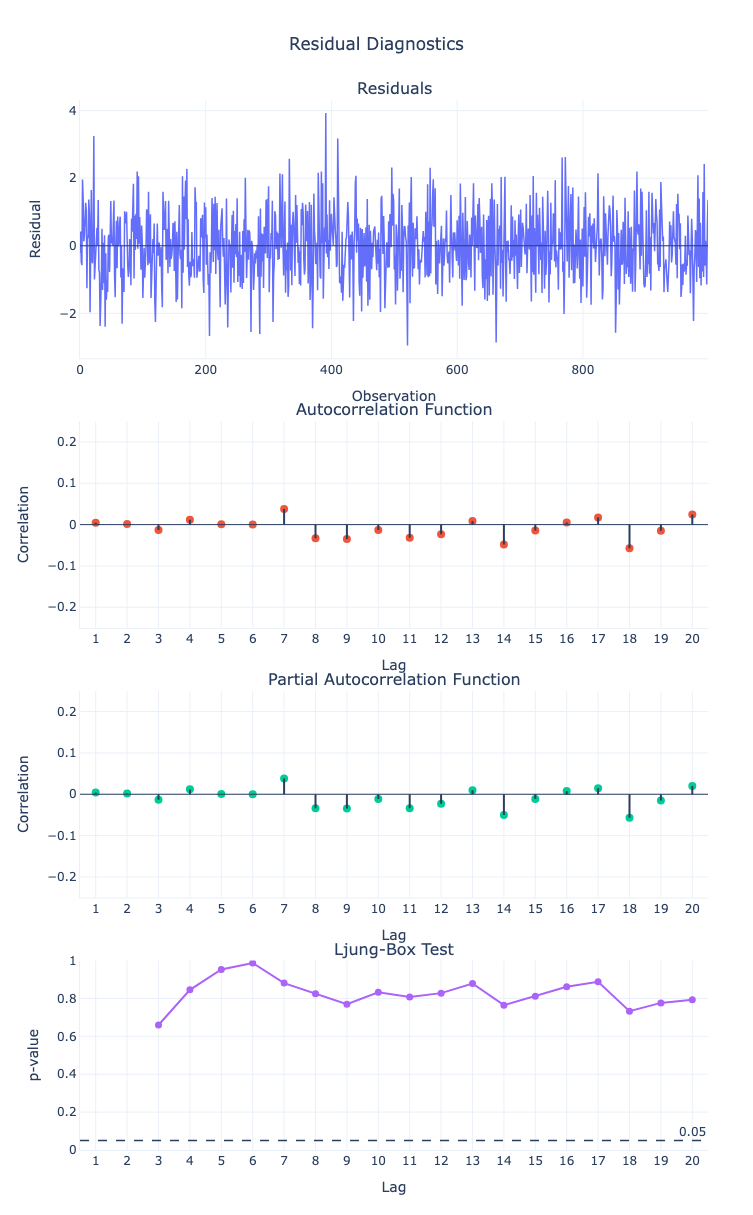

In [136]:
at.plot_residual_diagnostics(
    result,
    lags=20,
)

In [137]:
at.jarque_bera_test(result)

Jarque-Bera statistic    4.148883
Degrees of freedom       2.000000
P-value                  0.125627
Skewness                 0.149108
Kurtosis                 3.110988
Name: Jarque-Bera test, dtype: float64

## Near-common roots

In [138]:
np.random.seed(2468)

# Near-cancelling ARMA(1,1):
# AR inverse root = 0.70
# MA inverse root = 0.68
ar_near = np.array([1, -0.70])
ma_near = np.array([1, -0.68])

process_near = ArmaProcess(ar_near, ma_near)
y_near = process_near.generate_sample(nsample=2000)

result_near = ARIMA(
    y_near,
    order=(1, 0, 1),
    trend="n"
).fit()

print("AR parameter:", result_near.arparams)
print("MA parameter:", result_near.maparams)

at.root_diagnostics(result_near)

AR parameter: [0.43039912]
MA parameter: [-0.40549696]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,2.323425,2.323425,0.430399,0.430399
1,MA,1,2.466110,2.466110,0.405497,0.405497


In [139]:
at.common_roots(result_near, tol=0.05)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.430399,0.405497,0.024902,Near-common


In [140]:
at.root_summary(result_near)

Causal AR component            True
Invertible MA component        True
Common root pairs                 0
Near-common root pairs            1
Minimum AR-MA distance     0.024902
Name: Root diagnostics, dtype: object

In [141]:
at.parameter_correlation(result_near)

,ar.L1,ma.L1
ar.L1,1.000000,-0.999604
ma.L1,-0.999604,1.000000


In [142]:
at.ljung_box_test(result_near, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,3.697160,3,0.296077
10,14.798773,8,0.063178
20,17.604941,18,0.481949


In [143]:
at.residual_correlations(result_near, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,-0.001028,-0.001028,-0.043826,0.043826
1,2,-0.007978,-0.007979,-0.043826,0.043826
2,3,0.022316,0.022301,-0.043826,0.043826
3,4,-0.012212,-0.012241,-0.043826,0.043826
4,5,-0.033629,-0.033315,-0.043826,0.043826
5,6,0.007125,0.006391,-0.043826,0.043826
6,7,-0.030812,-0.030826,-0.043826,0.043826
7,8,0.043669,0.045187,-0.043826,0.043826
8,9,0.050257,0.048890,-0.043826,0.043826
9,10,-0.009450,-0.008352,-0.043826,0.043826


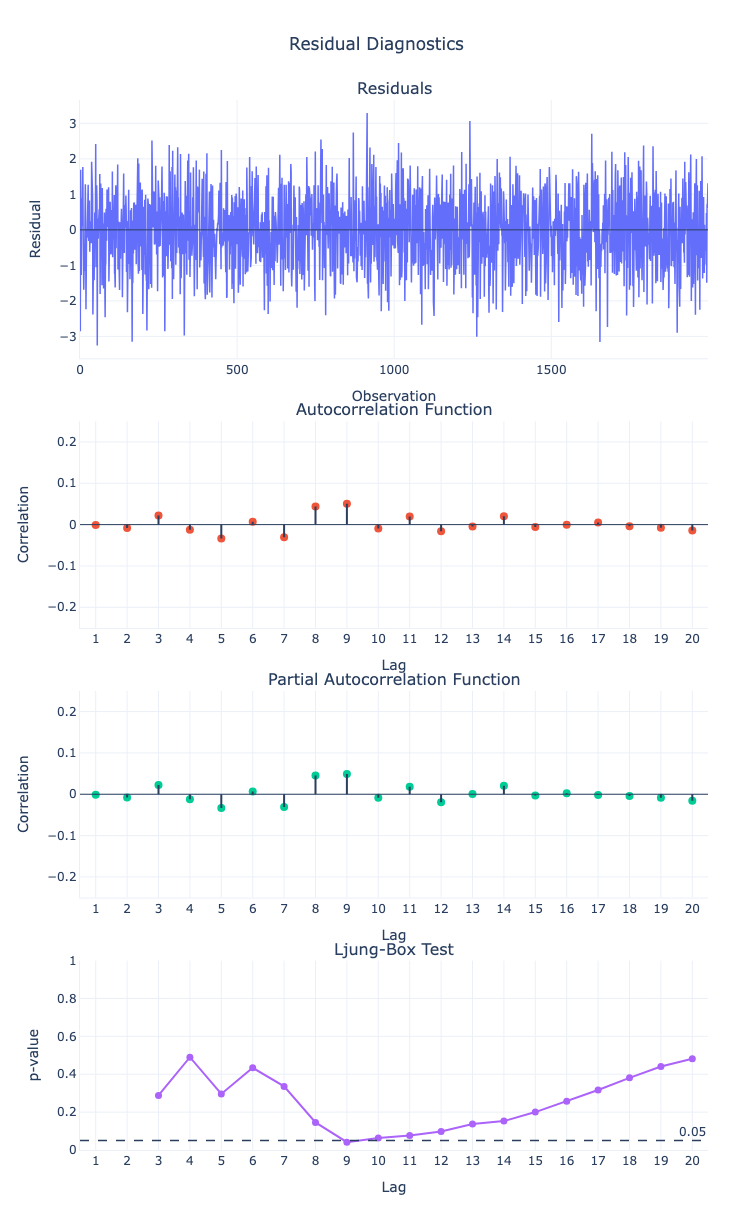

In [144]:
at.plot_residual_diagnostics(
    result_near,
    lags=20,
)

In [145]:
at.jarque_bera_test(result_near)

Jarque-Bera statistic    2.477895
Degrees of freedom       2.000000
P-value                  0.289689
Skewness                -0.068627
Kurtosis                 2.898225
Name: Jarque-Bera test, dtype: float64

## AR(2) Complex Roots

In [146]:
np.random.seed(1357)

# AR(2) with complex-conjugate roots
# y_t = 1.2 y_{t-1} - 0.5 y_{t-2} + eps_t
ar_complex = np.array([1, -1.2, 0.5])
ma_complex = np.array([1])

process_complex = ArmaProcess(ar_complex, ma_complex)
y_complex = process_complex.generate_sample(nsample=2000)

result_complex = ARIMA(
    y_complex,
    order=(2, 0, 0),
    trend="n"
).fit()

print("AR parameters:", result_complex.arparams)

at.root_diagnostics(result_complex)

AR parameters: [ 1.21813126 -0.50164691]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.214132-0.720637j,1.41189,0.609066+0.361505j,0.70827
1,AR,2,1.214132+0.720637j,1.41189,0.609066-0.361505j,0.70827


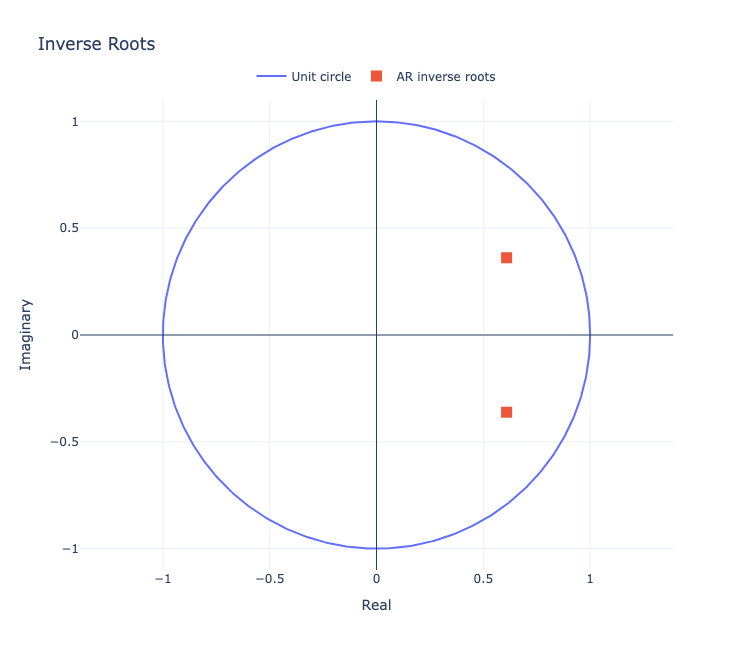

In [147]:
at.plot_inverse_roots(result_complex)

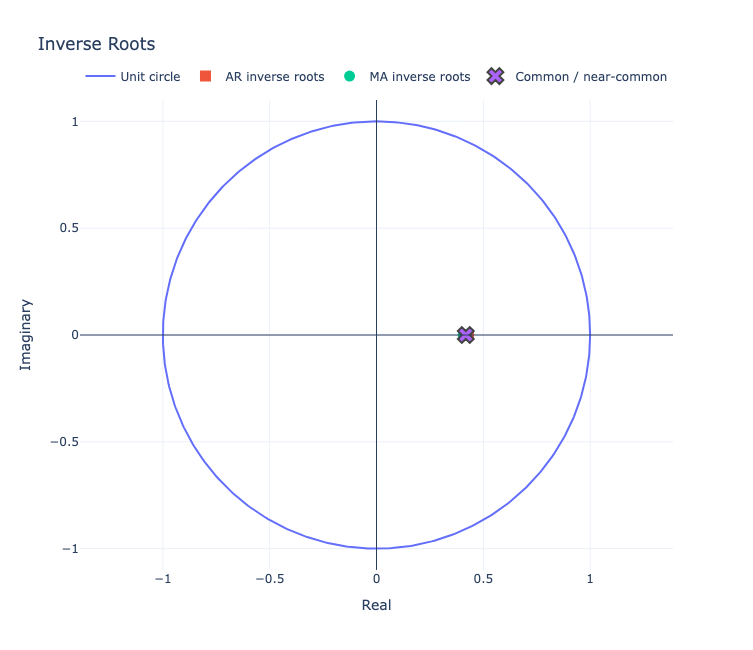

In [148]:
at.plot_inverse_roots(result_near)

In [149]:
at.root_summary(result_complex)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object

In [150]:
at.parameter_correlation(result_complex)

,ar.L1,ar.L2
ar.L1,1.000000,-0.812501
ar.L2,-0.812501,1.000000


In [151]:
at.joint_significance(
    result_complex,
    ["ar.L1", "ar.L2"]
)

Wald statistic        6186.003966
Degrees of freedom       2.000000
P-value                  0.000000
Name: Joint significance test, dtype: float64

In [152]:
at.ljung_box_test(result_complex, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,1.785702,3,0.618051
10,4.954630,8,0.762414
20,11.922463,18,0.851215


In [153]:
at.residual_correlations(result_complex, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,0.002885,0.002885,-0.043826,0.043826
1,2,0.000223,0.000215,-0.043826,0.043826
2,3,-0.017907,-0.017908,-0.043826,0.043826
3,4,-0.004654,-0.004552,-0.043826,0.043826
4,5,0.023225,0.023268,-0.043826,0.043826
5,6,-0.011008,-0.011470,-0.043826,0.043826
6,7,-0.011423,-0.011553,-0.043826,0.043826
7,8,-0.003803,-0.002909,-0.043826,0.043826
8,9,-0.032242,-0.032430,-0.043826,0.043826
9,10,-0.016441,-0.017343,-0.043826,0.043826


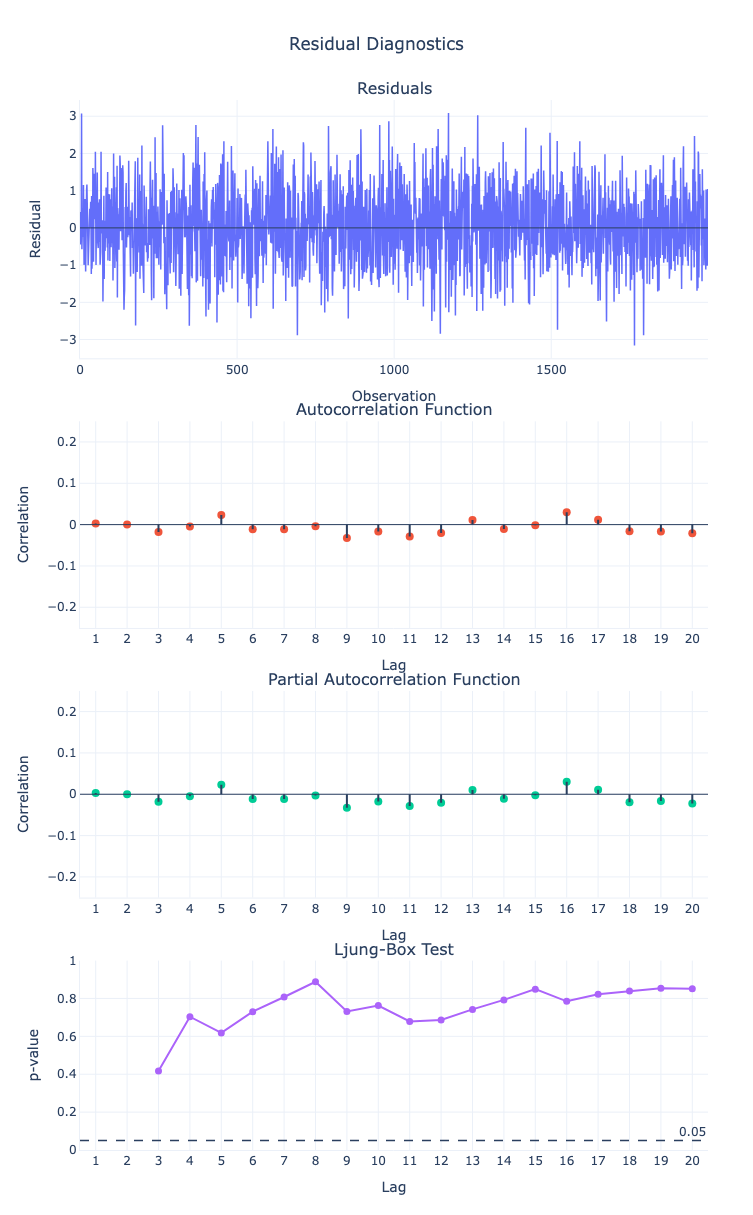

In [154]:
at.plot_residual_diagnostics(
    result_complex,
    lags=20,
)

In [155]:
at.jarque_bera_test(result_complex)

Jarque-Bera statistic    2.074076
Degrees of freedom       2.000000
P-value                  0.354503
Skewness                 0.051777
Kurtosis                 2.883622
Name: Jarque-Bera test, dtype: float64